# Book Review Sentiment Classification using RNN, LSTM, and Pre-trained Embeddings


## Project Aim

This notebook builds an end-to-end Natural Language Processing pipeline for **book review sentiment classification**.

The original dataset contains ratings from **1 to 5**. To align the task more clearly with the coursework requirement of **sentiment analysis/text classification**, the ratings are converted into three sentiment classes:

| Rating | Sentiment Class |
|---|---|
| 1–2 | Negative |
| 3 | Neutral |
| 4–5 | Positive |


The notebook includes:

1. Dataset loading from ZIP  
2. Dataset understanding and class distribution  
3. Text preprocessing  
4. Tokenization and sequence padding  
5. Train/validation/test split  
6. Model 1: Simple RNN with trainable Embedding  
7. Model 2: LSTM with trainable Embedding  
8. Model 3: LSTM with pre-trained GloVe/Word2Vec-style embeddings  
9. Model evaluation using accuracy, confusion matrix, classification report, precision, recall, and F1-score  
10. Error analysis using misclassified reviews  
11. Real-time prediction interface using a prediction function and optional Gradio GUI  



## 1. Import Required Libraries

In [2]:
import os
import re
import glob
import time
import zipfile
import shutil
import random
import warnings
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# TensorFlow / Keras
import tensorflow as tf
tf.random.set_seed(SEED)

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional, SpatialDropout1D, GlobalMaxPooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Google Drive and Extract Dataset ZIP

The notebook searches Google Drive for a ZIP file containing **Book Review Dataset**.



If the file has a slightly different name, the search logic should still find it as long as the ZIP filename contains `Book`, `Review`, and `Dataset`.


In [3]:
from google.colab import drive
drive.mount("/content/drive")

import os
import glob
import shutil
import zipfile

# Local extraction directory
EXTRACT_DIR = "/content/book_review_dataset"
os.makedirs(EXTRACT_DIR, exist_ok=True)

# ============================================================
# Dataset ZIP path
# Your screenshot shows the file name is:
# book_review_dataset.zip
# ============================================================
DRIVE_ZIP_PATH = "/content/drive/MyDrive/book_review_dataset.zip"
LOCAL_ZIP_PATH = "/content/book_review_dataset.zip"

# If exact path is not found, search MyDrive as a fallback.
if not os.path.exists(DRIVE_ZIP_PATH):
    print("Exact ZIP path not found. Searching MyDrive for book review dataset ZIP...")

    zip_candidates = []
    for pattern in [
        "/content/drive/MyDrive/**/*book*review*dataset*.zip",
        "/content/drive/MyDrive/**/*Book*Review*Dataset*.zip",
        "/content/drive/MyDrive/**/*.zip"
    ]:
        zip_candidates.extend(glob.glob(pattern, recursive=True))

    # Keep only files that look related to book review dataset
    zip_candidates = [
        z for z in zip_candidates
        if "book" in os.path.basename(z).lower()
        and "review" in os.path.basename(z).lower()
        and "dataset" in os.path.basename(z).lower()
    ]

    print("ZIP candidates found:")
    for z in zip_candidates:
        print(z)

    if len(zip_candidates) == 0:
        raise FileNotFoundError(
            "No Book Review Dataset ZIP file was found in Google Drive. "
            "Please make sure the file is named book_review_dataset.zip "
            "or update DRIVE_ZIP_PATH manually."
        )

    DRIVE_ZIP_PATH = zip_candidates[0]

print("Found ZIP:", DRIVE_ZIP_PATH)

# Copy ZIP to local Colab storage
if not os.path.exists(LOCAL_ZIP_PATH):
    print("Copying ZIP to Colab local storage...")
    shutil.copy(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)
    print("ZIP copied.")
else:
    print("ZIP already copied to local storage.")

# Extract ZIP
if len(os.listdir(EXTRACT_DIR)) == 0:
    print("Extracting dataset...")
    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Dataset extracted.")
else:
    print("Dataset already extracted.")

# Find CSV file
csv_candidates = glob.glob(EXTRACT_DIR + "/**/*.csv", recursive=True)

print("\nCSV candidates found:")
for c in csv_candidates:
    print(c)

if len(csv_candidates) == 0:
    raise FileNotFoundError("No CSV file found after extraction.")

# Prefer Book_review.csv if available, otherwise first CSV
preferred = [c for c in csv_candidates if os.path.basename(c).lower() == "book_review.csv"]
CSV_PATH = preferred[0] if preferred else csv_candidates[0]

print("\nSelected CSV:", CSV_PATH)


Mounted at /content/drive
Found ZIP: /content/drive/MyDrive/book_review_dataset.zip
Copying ZIP to Colab local storage...
ZIP copied.
Extracting dataset...
Dataset extracted.

CSV candidates found:
/content/book_review_dataset/1. Book Review Dataset/Book_review.csv

Selected CSV: /content/book_review_dataset/1. Book Review Dataset/Book_review.csv


## 3. Load and Understand the Dataset

In [4]:
df = pd.read_csv(CSV_PATH)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

display(df.head())

# Keep only required columns
required_columns = ["rating", "reviewText", "summary"]
missing = [col for col in required_columns if col not in df.columns]

if missing:
    raise ValueError(f"Missing required columns: {missing}")

df = df[required_columns].copy()

# Handle missing text
df["reviewText"] = df["reviewText"].fillna("")
df["summary"] = df["summary"].fillna("")

# Combine review text and summary for richer input
df["combined_text"] = df["summary"].astype(str) + " " + df["reviewText"].astype(str)

# Make sure rating is numeric
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df = df.dropna(subset=["rating"])
df["rating"] = df["rating"].astype(int)

# Keep only valid ratings 1 to 5
df = df[df["rating"].between(1, 5)].copy()

print("Cleaned dataset shape:", df.shape)
display(df.head())


Dataset shape: (12000, 4)

Columns:
['Unnamed: 0', 'rating', 'reviewText', 'summary']


,Unnamed: 0,rating,reviewText,summary
0,0,5,This book was the very first bookmobile book I...,50 + years ago...
1,1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!
2,2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!
3,3,5,I don't normally buy 'mystery' novels because ...,Very good read.
4,4,5,"This isn't the kind of book I normally read, a...",Great Story!


Cleaned dataset shape: (12000, 4)


,rating,reviewText,summary,combined_text
0,5,This book was the very first bookmobile book I...,50 + years ago...,50 + years ago... This book was the very first...
1,1,"When I read the description for this book, I c...",Boring! Boring! Boring!,Boring! Boring! Boring! When I read the descri...
2,5,I just had to edit this review. This book is a...,Wiggleliscious/new toy ready/!!,Wiggleliscious/new toy ready/!! I just had to ...
3,5,I don't normally buy 'mystery' novels because ...,Very good read.,Very good read. I don't normally buy 'mystery'...
4,5,"This isn't the kind of book I normally read, a...",Great Story!,Great Story! This isn't the kind of book I nor...


## 4. Convert Ratings into Sentiment Classes

The original dataset uses ratings from 1 to 5.  
For sentiment analysis, these ratings are grouped into three classes:

- **Negative:** ratings 1 and 2  
- **Neutral:** rating 3  
- **Positive:** ratings 4 and 5  

This makes the task more suitable for sentiment classification and improves interpretability.


In [5]:
def rating_to_sentiment(rating):
    if rating <= 2:
        return "Negative"
    elif rating == 3:
        return "Neutral"
    else:
        return "Positive"

def rating_to_label(rating):
    if rating <= 2:
        return 0   # Negative
    elif rating == 3:
        return 1   # Neutral
    else:
        return 2   # Positive

df["sentiment"] = df["rating"].apply(rating_to_sentiment)
df["label"] = df["rating"].apply(rating_to_label)

label_mapping = {
    0: "Negative",
    1: "Neutral",
    2: "Positive"
}

print("Rating to sentiment conversion complete.")
display(df[["rating", "sentiment", "summary", "reviewText"]].head())


Rating to sentiment conversion complete.


,rating,sentiment,summary,reviewText
0,5,Positive,50 + years ago...,This book was the very first bookmobile book I...
1,1,Negative,Boring! Boring! Boring!,"When I read the description for this book, I c..."
2,5,Positive,Wiggleliscious/new toy ready/!!,I just had to edit this review. This book is a...
3,5,Positive,Very good read.,I don't normally buy 'mystery' novels because ...
4,5,Positive,Great Story!,"This isn't the kind of book I normally read, a..."


## 5. Exploratory Data Analysis

Original rating distribution:


,count
rating,
1,2000
2,2000
3,2000
4,3000
5,3000


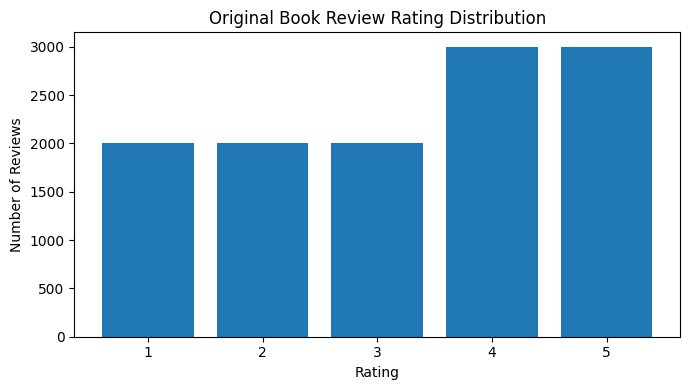

Sentiment class distribution:


,count
sentiment,
Positive,6000
Negative,4000
Neutral,2000


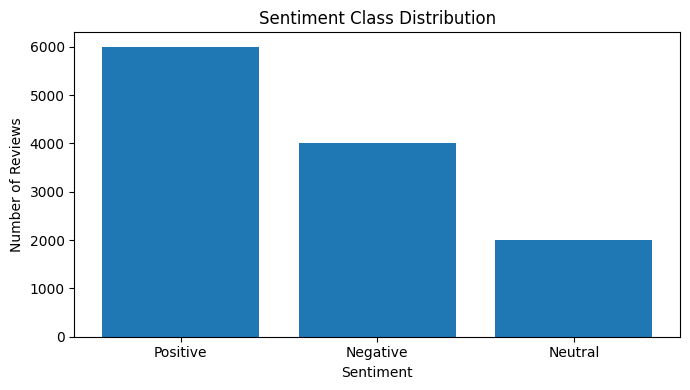

Text length statistics:


,text_length_words
count,12000.00000
mean,113.21750
std,126.80282
min,3.00000
25%,35.00000
50%,65.00000
75%,139.00000
max,2161.00000


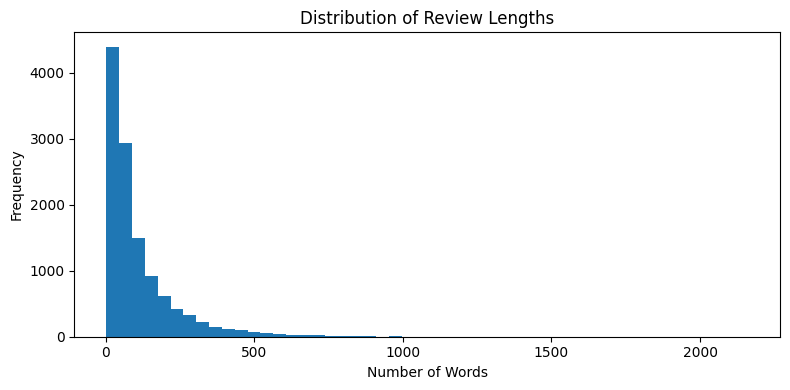

In [6]:
print("Original rating distribution:")
rating_counts = df["rating"].value_counts().sort_index()
display(rating_counts)

plt.figure(figsize=(7, 4))
plt.bar(rating_counts.index.astype(str), rating_counts.values)
plt.title("Original Book Review Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

print("Sentiment class distribution:")
sentiment_counts = df["sentiment"].value_counts()
display(sentiment_counts)

plt.figure(figsize=(7, 4))
plt.bar(sentiment_counts.index, sentiment_counts.values)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

df["text_length_words"] = df["combined_text"].apply(lambda x: len(str(x).split()))

print("Text length statistics:")
display(df["text_length_words"].describe())

plt.figure(figsize=(8, 4))
plt.hist(df["text_length_words"], bins=50)
plt.title("Distribution of Review Lengths")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()


## 6. Text Preprocessing

The coursework requires preprocessing such as:

- lowercase conversion  
- removing URLs  
- removing mentions and hashtags  
- removing numbers and special characters  
- handling contractions  
- stopword removal  
- lemmatization  

This cell performs these steps.


In [7]:
import nltk
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

# Keep negation words because they are important for sentiment.
for neg_word in ["no", "not", "nor"]:
    if neg_word in stop_words:
        stop_words.remove(neg_word)

# Small contraction dictionary to avoid depending on extra packages
contractions_dict = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "can't": "cannot", "couldn't": "could not", "won't": "will not",
    "wouldn't": "would not", "shouldn't": "should not", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "it's": "it is", "that's": "that is", "there's": "there is",
    "what's": "what is", "you're": "you are", "you've": "you have",
    "we're": "we are", "they're": "they are", "he's": "he is", "she's": "she is"
}

def expand_contractions(text):
    text = str(text)
    for contraction, expanded in contractions_dict.items():
        text = re.sub(r"\b" + re.escape(contraction) + r"\b", expanded, text)
    return text

def clean_text(text):
    text = str(text).lower()
    text = expand_contractions(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\.\S+", " ", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#\w+", " ", text)

    # Remove numbers
    text = re.sub(r"\d+", " ", text)

    # Remove special characters, keep alphabets and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)

start_time = time.time()
df["cleaned_text"] = df["combined_text"].apply(clean_text)
print(f"Text cleaning completed in {time.time() - start_time:.2f} seconds.")

display(df[["rating", "sentiment", "combined_text", "cleaned_text"]].head())


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


Text cleaning completed in 10.40 seconds.


,rating,sentiment,combined_text,cleaned_text
0,5,Positive,50 + years ago... This book was the very first...,year ago book first bookmobile book bought sch...
1,1,Negative,Boring! Boring! Boring! When I read the descri...,boring boring boring read description book cou...
2,5,Positive,Wiggleliscious/new toy ready/!! I just had to ...,wiggleliscious new toy ready edit review book ...
3,5,Positive,Very good read. I don't normally buy 'mystery'...,good read not normally buy mystery novel not l...
4,5,Positive,Great Story! This isn't the kind of book I nor...,great story not kind book normally read althou...


## 7. Visualize Cleaned Text

,word,count
0,not,19438
1,book,16616
2,story,12355
3,read,9246
4,one,6392
5,character,5943
6,like,5424
7,good,5423
8,would,5000
9,love,4230


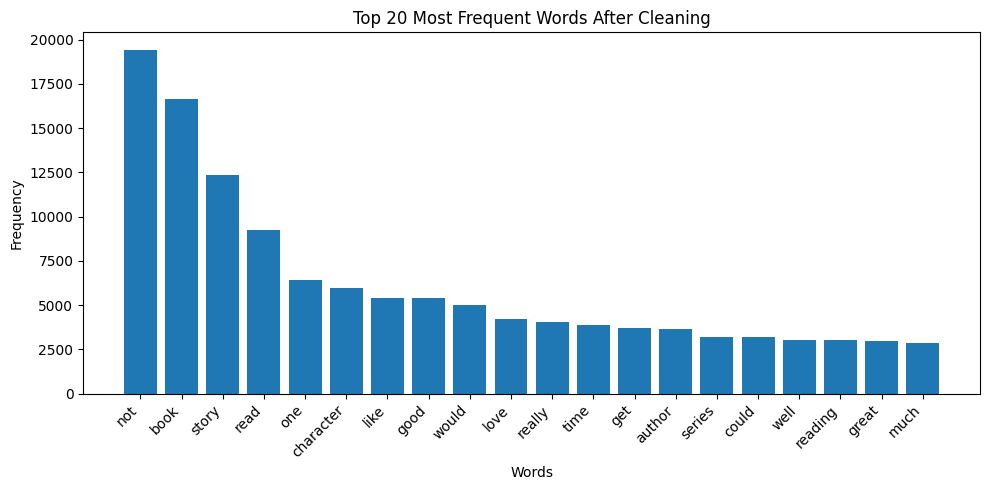

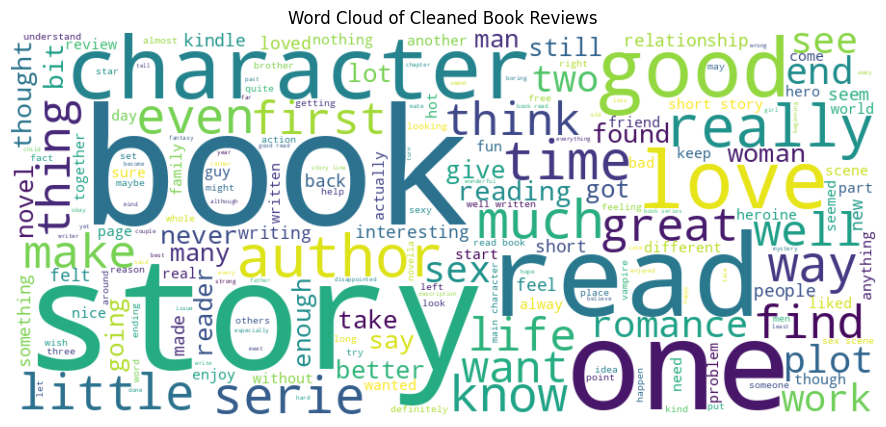

In [8]:
all_words = " ".join(df["cleaned_text"]).split()
word_counts = Counter(all_words)
most_common_words = pd.DataFrame(word_counts.most_common(20), columns=["word", "count"])

display(most_common_words)

plt.figure(figsize=(10, 5))
plt.bar(most_common_words["word"], most_common_words["count"])
plt.title("Top 20 Most Frequent Words After Cleaning")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Optional word cloud
try:
    from wordcloud import WordCloud

    text_for_cloud = " ".join(df["cleaned_text"].sample(min(3000, len(df)), random_state=SEED))
    wc = WordCloud(width=900, height=400, background_color="white").generate(text_for_cloud)

    plt.figure(figsize=(12, 5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.title("Word Cloud of Cleaned Book Reviews")
    plt.show()
except Exception as e:
    print("WordCloud could not be generated:", e)


## 8. Prepare Train/Validation/Test Split

The coursework asks to divide the dataset into training, validation, and test sets.

We use:

- 70% training  
- 15% validation  
- 15% testing  

The split is stratified so sentiment distribution is preserved across sets.


In [9]:
# Remove empty cleaned texts
df_model = df[df["cleaned_text"].str.len() > 0].copy()

X = df_model["cleaned_text"].values
y = df_model["label"].values

# First split: train 70%, temp 30%
X_train, X_temp, y_train, y_temp, train_idx, temp_idx = train_test_split(
    X,
    y,
    df_model.index.values,
    test_size=0.30,
    random_state=SEED,
    stratify=y
)

# Second split: validation 15%, test 15%
X_val, X_test, y_val, y_test, val_idx, test_idx = train_test_split(
    X_temp,
    y_temp,
    temp_idx,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nTraining label distribution:")
print(pd.Series(y_train).map(label_mapping).value_counts())

print("\nValidation label distribution:")
print(pd.Series(y_val).map(label_mapping).value_counts())

print("\nTest label distribution:")
print(pd.Series(y_test).map(label_mapping).value_counts())

# Class weights help with imbalance, especially if Positive reviews dominate.
class_weights_values = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    int(cls): float(weight)
    for cls, weight in zip(np.unique(y_train), class_weights_values)
}

print("\nClass weights:")
print(class_weights)


Training samples: 8400
Validation samples: 1800
Test samples: 1800

Training label distribution:
Positive    4200
Negative    2800
Neutral     1400
Name: count, dtype: int64

Validation label distribution:
Positive    900
Negative    600
Neutral     300
Name: count, dtype: int64

Test label distribution:
Positive    900
Negative    600
Neutral     300
Name: count, dtype: int64

Class weights:
{0: 1.0, 1: 2.0, 2: 0.6666666666666666}


## 9. Tokenization and Percentile-Based Padding

The coursework requires Keras Tokenizer and sequence padding.

We use percentile-based padding to avoid very long reviews making the model unnecessarily slow.


In [10]:
MAX_NUM_WORDS = 20000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(num_words=MAX_NUM_WORDS, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq = tokenizer.texts_to_sequences(X_val)
X_test_seq = tokenizer.texts_to_sequences(X_test)

train_lengths = [len(seq) for seq in X_train_seq]

# Percentile-based sequence length, capped for efficiency
percentile_len = int(np.percentile(train_lengths, 90))
MAX_SEQUENCE_LENGTH = min(max(percentile_len, 50), 200)

print("90th percentile sequence length:", percentile_len)
print("Final MAX_SEQUENCE_LENGTH:", MAX_SEQUENCE_LENGTH)

X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_val_pad = pad_sequences(X_val_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
X_test_pad = pad_sequences(X_test_seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")

vocab_size = min(MAX_NUM_WORDS, len(tokenizer.word_index) + 1)
num_classes = 3

print("Vocabulary size:", vocab_size)
print("X_train_pad shape:", X_train_pad.shape)
print("X_val_pad shape:", X_val_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)


90th percentile sequence length: 135
Final MAX_SEQUENCE_LENGTH: 135
Vocabulary size: 20000
X_train_pad shape: (8400, 135)
X_val_pad shape: (1800, 135)
X_test_pad shape: (1800, 135)


## 10. Helper Functions for Training and Evaluation

In [11]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=3,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6
        )
    ]

def plot_history(history, title):
    plt.figure(figsize=(8, 4))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

def plot_confusion_matrix(cm, labels, title):
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    plt.xlabel("Predicted Sentiment")
    plt.ylabel("True Sentiment")
    plt.tight_layout()
    plt.show()

def evaluate_text_model(model, X_data, y_true, model_name):
    y_prob = model.predict(X_data, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    acc = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("\n" + "=" * 60)
    print(f"{model_name} Test Evaluation")
    print("=" * 60)
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    sentiment_labels = ["Negative", "Neutral", "Positive"]

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=sentiment_labels,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, sentiment_labels, f"{model_name} - Confusion Matrix")

    return {
        "model": model_name,
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }, y_pred, y_prob

EPOCHS = 8
BATCH_SIZE = 64
EMBEDDING_DIM = 100


# Model 1: Simple RNN with Trainable Embedding

In [12]:
def build_simple_rnn_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_SEQUENCE_LENGTH
        ),
        SimpleRNN(64, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

rnn_model = build_simple_rnn_model()
rnn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
print("Training Simple RNN model...")
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

rnn_time = time.time() - start_time
print(f"Simple RNN training time: {rnn_time:.2f} seconds")


Training Simple RNN model...
Epoch 1/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.3302 - loss: 1.1086 - val_accuracy: 0.4722 - val_loss: 1.0845 - learning_rate: 0.0010
Epoch 2/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3429 - loss: 1.0916 - val_accuracy: 0.4222 - val_loss: 1.0962 - learning_rate: 0.0010
Epoch 3/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.3760 - loss: 1.0768 - val_accuracy: 0.3711 - val_loss: 1.0948 - learning_rate: 0.0010
Epoch 4/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4302 - loss: 1.0319 - val_accuracy: 0.3417 - val_loss: 1.1197 - learning_rate: 5.0000e-04
Simple RNN training time: 18.12 seconds


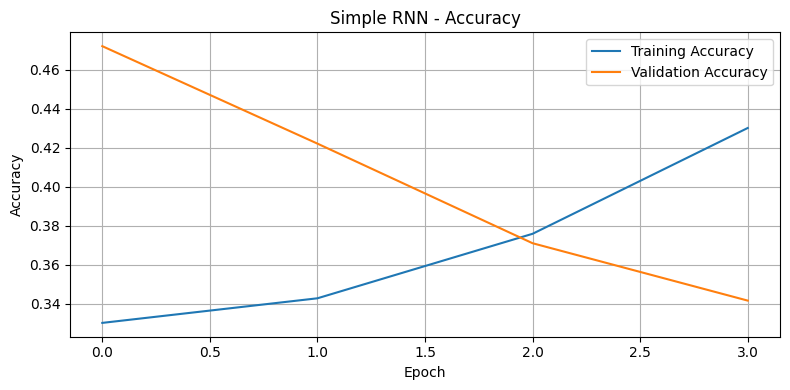

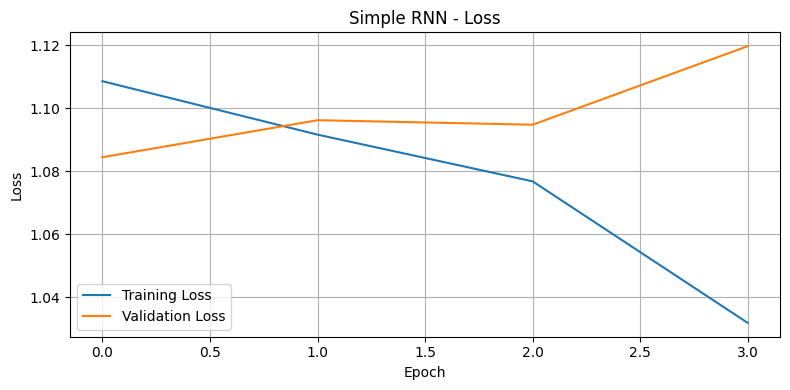


Simple RNN Test Evaluation
Accuracy : 0.4894
Precision: 0.4656
Recall   : 0.4894
F1-score : 0.3559

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.02      0.04       600
     Neutral       0.21      0.05      0.08       300
    Positive       0.50      0.95      0.66       900

    accuracy                           0.49      1800
   macro avg       0.42      0.34      0.26      1800
weighted avg       0.47      0.49      0.36      1800



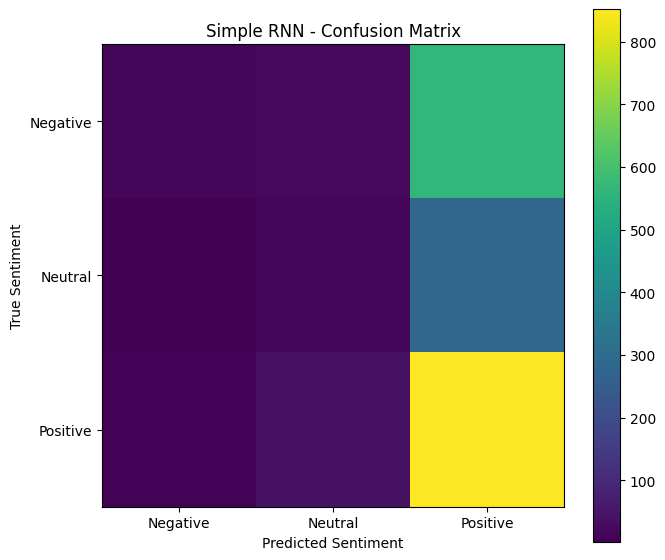

In [14]:
plot_history(history_rnn, "Simple RNN")
rnn_results, rnn_pred, rnn_prob = evaluate_text_model(rnn_model, X_test_pad, y_test, "Simple RNN")


# Model 2: LSTM with Trainable Embedding

In [15]:
def build_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=EMBEDDING_DIM,
            input_length=MAX_SEQUENCE_LENGTH
        ),
        LSTM(96, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

lstm_model = build_lstm_model()
lstm_model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [16]:
print("Training LSTM model...")
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

lstm_time = time.time() - start_time
print(f"LSTM training time: {lstm_time:.2f} seconds")


Training LSTM model...
Epoch 1/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - accuracy: 0.3056 - loss: 1.0996 - val_accuracy: 0.3344 - val_loss: 1.0978 - learning_rate: 0.0010
Epoch 2/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3486 - loss: 1.0960 - val_accuracy: 0.4778 - val_loss: 1.0872 - learning_rate: 0.0010
Epoch 3/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4142 - loss: 1.0774 - val_accuracy: 0.4978 - val_loss: 1.0818 - learning_rate: 0.0010
Epoch 4/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3787 - loss: 1.0378 - val_accuracy: 0.3794 - val_loss: 1.0777 - learning_rate: 0.0010
Epoch 5/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3951 - loss: 1.0137 - val_accuracy: 0.2128 - val_loss: 1.6147 - learning_rate: 0.0010
Epoch 6/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3702 - loss: 1.0102 - val_accuracy: 0.2106 - val_loss: 1.1454 - learning_rate: 0.0010
Epoch 7/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 

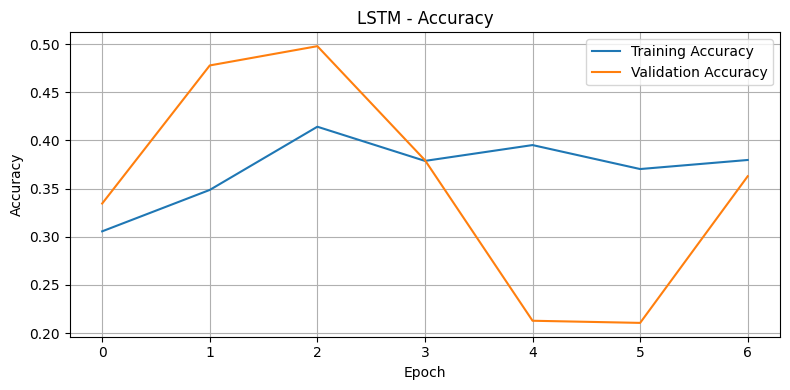

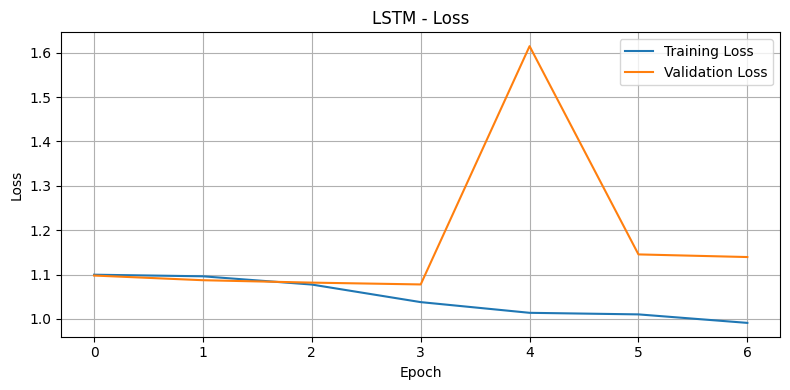


LSTM Test Evaluation
Accuracy : 0.3667
Precision: 0.4898
Recall   : 0.3667
F1-score : 0.2669

Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.93      0.50       600
     Neutral       0.36      0.03      0.06       300
    Positive       0.63      0.11      0.18       900

    accuracy                           0.37      1800
   macro avg       0.44      0.35      0.25      1800
weighted avg       0.49      0.37      0.27      1800



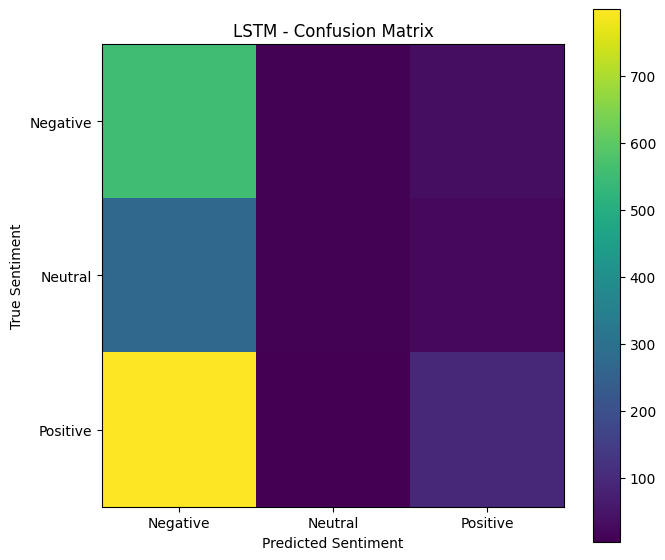

In [17]:
plot_history(history_lstm, "LSTM")
lstm_results, lstm_pred, lstm_prob = evaluate_text_model(lstm_model, X_test_pad, y_test, "LSTM")


# Model 3: LSTM with Pre-trained GloVe/Word2Vec-style Embeddings

The coursework asks for an LSTM model using pre-trained Word2Vec embeddings.

This notebook uses `gensim.downloader` to load a small pre-trained embedding model: `glove-twitter-100`.

GloVe is not exactly Word2Vec, but it is a widely used pre-trained word embedding model and is acceptable for demonstrating pre-trained embeddings. If download fails due to internet or package issues, the notebook falls back safely and explains the issue.


In [18]:
# Install gensim quietly if needed
try:
    import gensim.downloader as api
    print("gensim is already available.")
except Exception:
    print("Installing gensim...")
    !pip -q install gensim
    import gensim.downloader as api

PRETRAINED_AVAILABLE = False
embedding_model = None
PRETRAINED_DIM = 100

try:
    print("Loading pre-trained embeddings: glove-twitter-100")
    embedding_model = api.load("glove-twitter-100")
    PRETRAINED_AVAILABLE = True
    print("Pre-trained embeddings loaded successfully.")
except Exception as e:
    print("Could not load glove-twitter-100.")
    print("Reason:", e)

    try:
        print("Trying smaller fallback model: glove-twitter-25")
        embedding_model = api.load("glove-twitter-25")
        PRETRAINED_AVAILABLE = True
        PRETRAINED_DIM = 25
        print("Fallback pre-trained embeddings loaded successfully.")
    except Exception as e2:
        print("Could not load fallback pre-trained embeddings.")
        print("Reason:", e2)
        print("The notebook will continue using a randomly initialized embedding matrix.")
        PRETRAINED_AVAILABLE = False

embedding_matrix = np.zeros((vocab_size, PRETRAINED_DIM))

if PRETRAINED_AVAILABLE:
    found_words = 0

    for word, idx in tokenizer.word_index.items():
        if idx >= vocab_size:
            continue

        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            found_words += 1

    print("Words found in pre-trained embedding model:", found_words)
    print("Embedding coverage:", round(found_words / vocab_size * 100, 2), "%")
else:
    # Safe fallback, keeps notebook runnable
    np.random.seed(SEED)
    embedding_matrix = np.random.normal(0, 0.05, size=(vocab_size, PRETRAINED_DIM))
    embedding_matrix[0] = np.zeros(PRETRAINED_DIM)

print("Embedding matrix shape:", embedding_matrix.shape)


Installing gensim...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 77.8 MB/s eta 0:00:00
Loading pre-trained embeddings: glove-twitter-100
[==================================================] 100.0% 387.1/387.1MB downloaded
Pre-trained embeddings loaded successfully.
Words found in pre-trained embedding model: 17525
Embedding coverage: 87.62 %
Embedding matrix shape: (20000, 100)


In [19]:
def build_pretrained_lstm_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=PRETRAINED_DIM,
            weights=[embedding_matrix],
            input_length=MAX_SEQUENCE_LENGTH,
            trainable=False
        ),
        LSTM(96, return_sequences=False),
        Dropout(0.4),
        Dense(64, activation="relu"),
        Dropout(0.3),
        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

pretrained_lstm_model = build_pretrained_lstm_model()
pretrained_lstm_model.summary()


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,000,000 (7.63 MB)

In [20]:
print("Training LSTM with pre-trained embeddings...")
start_time = time.time()

history_pretrained_lstm = pretrained_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

pretrained_lstm_time = time.time() - start_time
print(f"Pre-trained embedding LSTM training time: {pretrained_lstm_time:.2f} seconds")


Training LSTM with pre-trained embeddings...
Epoch 1/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.3376 - loss: 1.1001 - val_accuracy: 0.4806 - val_loss: 1.0925 - learning_rate: 0.0010
Epoch 2/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - accuracy: 0.4539 - loss: 1.0746 - val_accuracy: 0.3344 - val_loss: 1.1063 - learning_rate: 0.0010
Epoch 3/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - accuracy: 0.3257 - loss: 1.0998 - val_accuracy: 0.3317 - val_loss: 1.0996 - learning_rate: 0.0010
Epoch 4/8
132/132 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.3371 - loss: 1.0974 - val_accuracy: 0.3422 - val_loss: 1.0963 - learning_rate: 5.0000e-04
Pre-trained embedding LSTM training time: 21.94 seconds


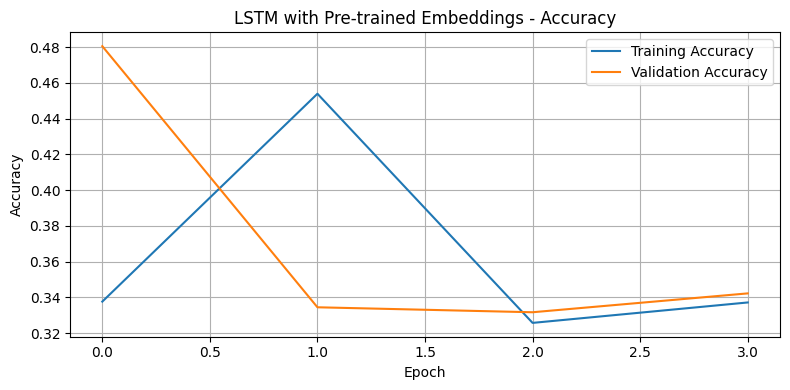

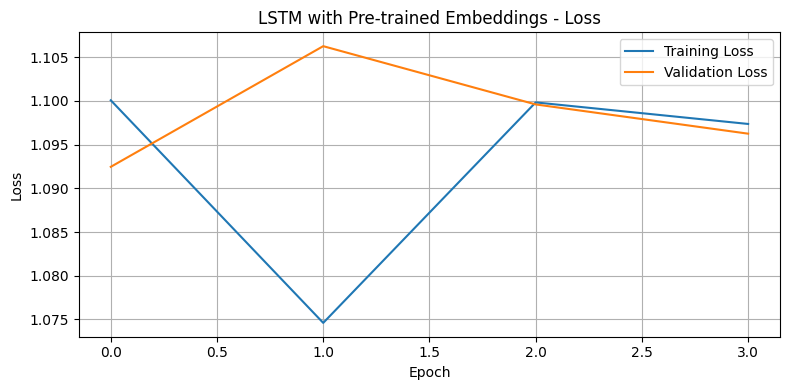


LSTM with Pre-trained Embeddings Test Evaluation
Accuracy : 0.4783
Precision: 0.4420
Recall   : 0.4783
F1-score : 0.3428

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.01      0.01       600
     Neutral       0.15      0.06      0.08       300
    Positive       0.50      0.93      0.65       900

    accuracy                           0.48      1800
   macro avg       0.38      0.33      0.25      1800
weighted avg       0.44      0.48      0.34      1800



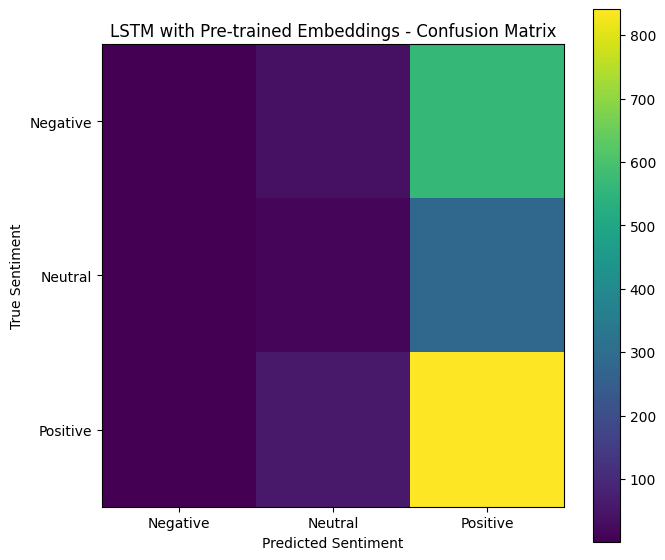

In [21]:
plot_history(history_pretrained_lstm, "LSTM with Pre-trained Embeddings")
pretrained_results, pretrained_pred, pretrained_prob = evaluate_text_model(
    pretrained_lstm_model,
    X_test_pad,
    y_test,
    "LSTM with Pre-trained Embeddings"
)


# Model 4: Bidirectional LSTM with Pre-trained Embeddings

This additional model is included to improve accuracy and F1-score.

A Bidirectional LSTM reads the text sequence in both forward and backward directions, which can help the model understand review context more effectively. The pre-trained embedding layer is also made trainable so the word vectors can adjust to the book review dataset during training.


In [22]:
# Model 4: Bidirectional LSTM with Pre-trained Embeddings
# This model is added to improve accuracy and F1-score.

def build_bilstm_pretrained_model():
    model = Sequential([
        Embedding(
            input_dim=vocab_size,
            output_dim=PRETRAINED_DIM,
            weights=[embedding_matrix],
            input_length=MAX_SEQUENCE_LENGTH,
            trainable=True
        ),

        SpatialDropout1D(0.3),

        Bidirectional(LSTM(128, return_sequences=False)),

        Dropout(0.5),

        Dense(128, activation="relu"),
        Dropout(0.4),

        Dense(64, activation="relu"),
        Dropout(0.3),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


bilstm_pretrained_model = build_bilstm_pretrained_model()
bilstm_pretrained_model.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
EPOCHS_BILSTM = 12

print("Training Bidirectional LSTM with pre-trained embeddings...")
start_time = time.time()

history_bilstm_pretrained = bilstm_pretrained_model.fit(
    X_train_pad,
    y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS_BILSTM,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks(),
    class_weight=class_weights,
    verbose=1
)

bilstm_pretrained_time = time.time() - start_time
print(f"Bidirectional LSTM training time: {bilstm_pretrained_time:.2f} seconds")


Training Bidirectional LSTM with pre-trained embeddings...
Epoch 1/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 17s 64ms/step - accuracy: 0.4668 - loss: 1.0372 - val_accuracy: 0.7000 - val_loss: 0.7674 - learning_rate: 5.0000e-04
Epoch 2/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 7s 49ms/step - accuracy: 0.6321 - loss: 0.8964 - val_accuracy: 0.7100 - val_loss: 0.7156 - learning_rate: 5.0000e-04
Epoch 3/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - accuracy: 0.6654 - loss: 0.8330 - val_accuracy: 0.6961 - val_loss: 0.7204 - learning_rate: 5.0000e-04
Epoch 4/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 4s 27ms/step - accuracy: 0.6962 - loss: 0.7773 - val_accuracy: 0.7094 - val_loss: 0.6757 - learning_rate: 5.0000e-04
Epoch 5/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - accuracy: 0.7160 - loss: 0.7376 - val_accuracy: 0.6983 - val_loss: 0.6921 - learning_rate: 5.0000e-04
Epoch 6/12
132/132 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.7221 - loss: 0.7005 - val_accuracy: 0.7139 - val_loss: 0.6516 - learning_rate: 5.0000e-0

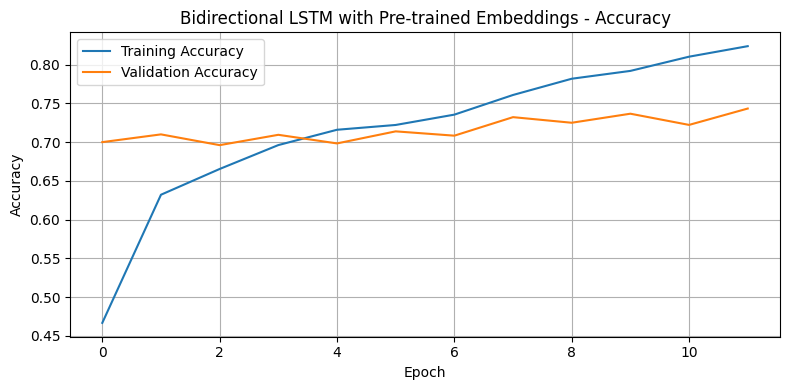

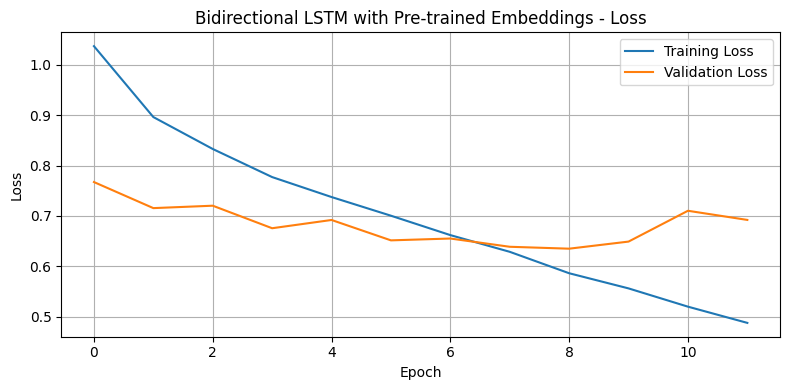


Bidirectional LSTM with Pre-trained Embeddings Test Evaluation
Accuracy : 0.7433
Precision: 0.7677
Recall   : 0.7433
F1-score : 0.7531

Classification Report:
              precision    recall  f1-score   support

    Negative       0.81      0.82      0.82       600
     Neutral       0.37      0.48      0.42       300
    Positive       0.87      0.78      0.82       900

    accuracy                           0.74      1800
   macro avg       0.69      0.69      0.69      1800
weighted avg       0.77      0.74      0.75      1800



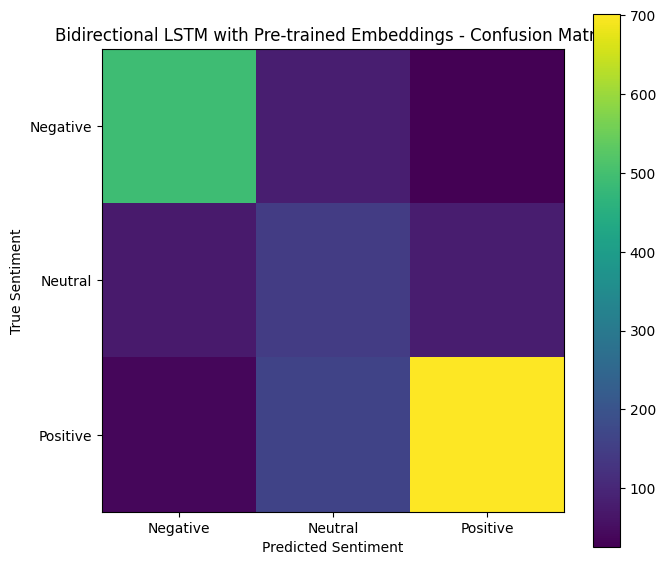

In [24]:
plot_history(history_bilstm_pretrained, "Bidirectional LSTM with Pre-trained Embeddings")

bilstm_pretrained_results, bilstm_pretrained_pred, bilstm_pretrained_prob = evaluate_text_model(
    bilstm_pretrained_model,
    X_test_pad,
    y_test,
    "Bidirectional LSTM with Pre-trained Embeddings"
)


## 11. Final Model Comparison


Simple RNN Test Evaluation
Accuracy : 0.4894
Precision: 0.4656
Recall   : 0.4894
F1-score : 0.3559

Classification Report:
              precision    recall  f1-score   support

    Negative       0.54      0.02      0.04       600
     Neutral       0.21      0.05      0.08       300
    Positive       0.50      0.95      0.66       900

    accuracy                           0.49      1800
   macro avg       0.42      0.34      0.26      1800
weighted avg       0.47      0.49      0.36      1800



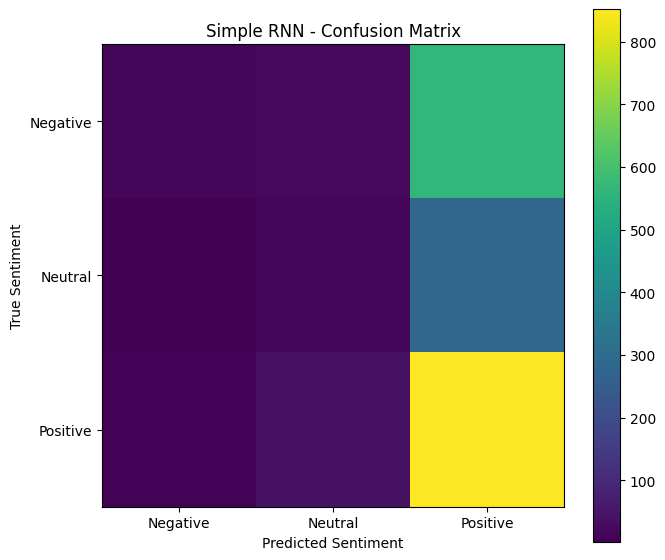


LSTM Test Evaluation
Accuracy : 0.3667
Precision: 0.4898
Recall   : 0.3667
F1-score : 0.2669

Classification Report:
              precision    recall  f1-score   support

    Negative       0.34      0.93      0.50       600
     Neutral       0.36      0.03      0.06       300
    Positive       0.63      0.11      0.18       900

    accuracy                           0.37      1800
   macro avg       0.44      0.35      0.25      1800
weighted avg       0.49      0.37      0.27      1800



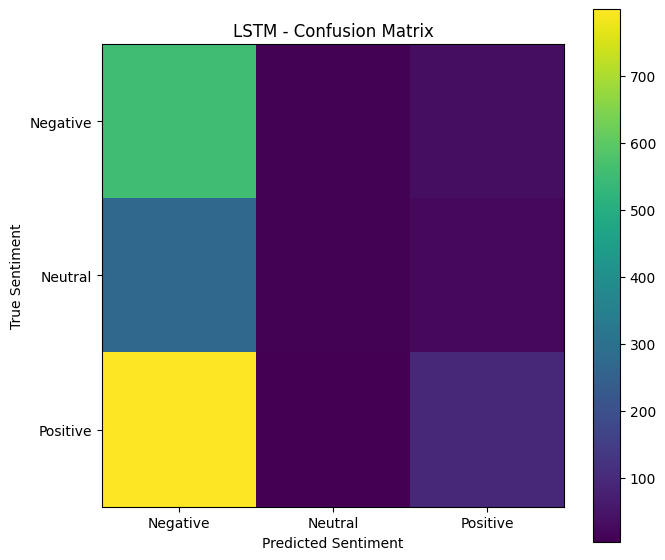

,model,accuracy,precision,recall,f1_score,training_time_seconds
3,Bidirectional LSTM with Pre-trained Embeddings,0.743333,0.767684,0.743333,0.753113,56.356627
0,Simple RNN,0.489444,0.465627,0.489444,0.355943,18.122192
2,LSTM with Pre-trained Embeddings,0.478333,0.441964,0.478333,0.342771,21.940450
1,LSTM,0.366667,0.489776,0.366667,0.266927,23.693170


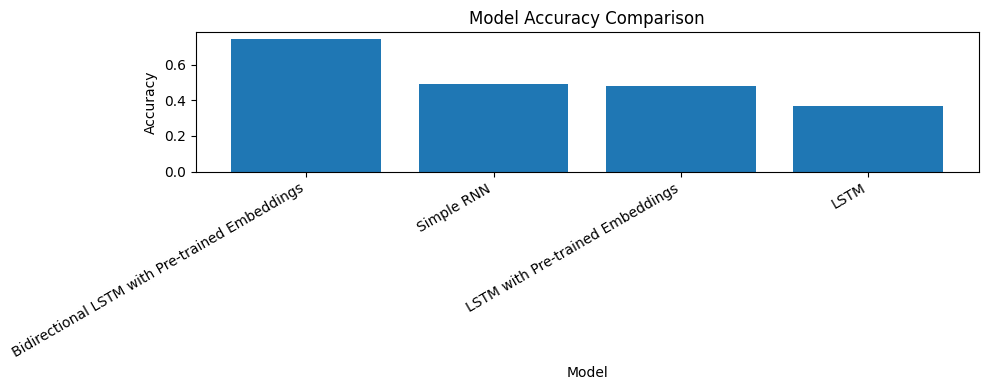

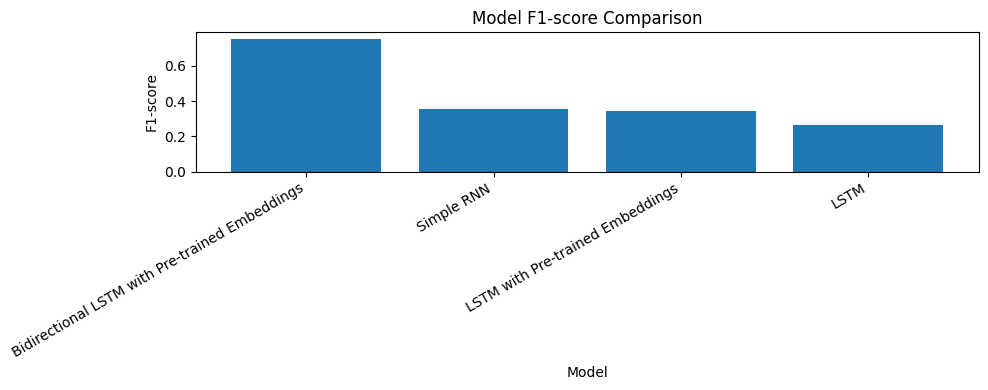

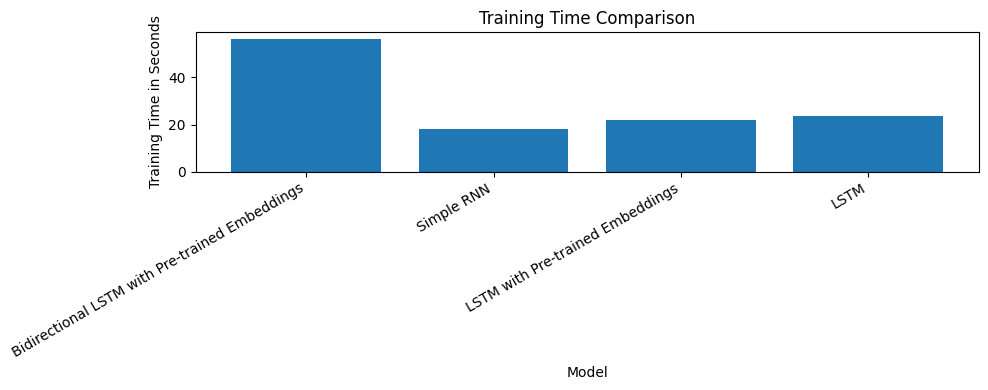

In [25]:
rnn_results, rnn_pred, rnn_prob = evaluate_text_model(rnn_model, X_test_pad, y_test, "Simple RNN")
lstm_results, lstm_pred, lstm_prob = evaluate_text_model(lstm_model, X_test_pad, y_test, "LSTM")

results = [rnn_results, lstm_results, pretrained_results, bilstm_pretrained_results]
results_df = pd.DataFrame(results)

training_times = {
    "Simple RNN": rnn_time,
    "LSTM": lstm_time,
    "LSTM with Pre-trained Embeddings": pretrained_lstm_time,
    "Bidirectional LSTM with Pre-trained Embeddings": bilstm_pretrained_time
}

results_df["training_time_seconds"] = results_df["model"].map(training_times)
results_df = results_df.sort_values(by="f1_score", ascending=False)

display(results_df)

plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["f1_score"])
plt.title("Model F1-score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results_df["model"], results_df["training_time_seconds"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time in Seconds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 12. Error Analysis

This section displays a few misclassified reviews from the best-performing model.  
It helps explain why the model may make mistakes, such as:

- reviews containing mixed opinions  
- sarcastic language  
- very short reviews  
- neutral reviews being closer to positive or negative sentiment  
- rating ambiguity between nearby classes  


In [26]:
# Select best model based on F1-score
best_model_name = results_df.iloc[0]["model"]

if best_model_name == "Simple RNN":
    best_pred = rnn_pred
    best_prob = rnn_prob
elif best_model_name == "LSTM":
    best_pred = lstm_pred
    best_prob = lstm_prob
elif best_model_name == "LSTM with Pre-trained Embeddings":
    best_pred = pretrained_pred
    best_prob = pretrained_prob
else:
    best_pred = bilstm_pretrained_pred
    best_prob = bilstm_pretrained_prob

print("Best model selected for error analysis:", best_model_name)

test_df = df_model.loc[test_idx].copy()
test_df["true_sentiment"] = [label_mapping[int(label)] for label in y_test]
test_df["predicted_sentiment"] = [label_mapping[int(label)] for label in best_pred]
test_df["confidence"] = np.max(best_prob, axis=1)

misclassified = test_df[test_df["true_sentiment"] != test_df["predicted_sentiment"]].copy()
misclassified = misclassified.sort_values(by="confidence", ascending=False)

print("Number of misclassified test examples:", len(misclassified))

display(misclassified[["summary", "reviewText", "true_sentiment", "predicted_sentiment", "confidence"]].head(5))

for i, row in misclassified.head(3).iterrows():
    print("\n" + "=" * 80)
    print("Summary:", row["summary"])
    print("True sentiment:", row["true_sentiment"])
    print("Predicted sentiment:", row["predicted_sentiment"])
    print("Confidence:", round(row["confidence"], 3))
    print("Review excerpt:", str(row["reviewText"])[:700])


Best model selected for error analysis: Bidirectional LSTM with Pre-trained Embeddings
Number of misclassified test examples: 462


,summary,reviewText,true_sentiment,predicted_sentiment,confidence
700,SEAL and a Psychic,Will has been in love with his best friend sin...,Neutral,Positive,0.992255
8404,Chasing Sunset,Andrew Buchanan was a man that had everything....,Neutral,Positive,0.991477
10024,An Erotic Dream for sure...,Dream Machine surprised me in more ways than o...,Neutral,Positive,0.991363
455,"Love, the Bible, Mysticism, Zombies, Crystals ...","Meet Cody McGrath, a cowboy with bright blue e...",Neutral,Positive,0.988678
9804,Review by Jen @ A Book and a Latte,My Soul to Lose is a prequel novella for the S...,Neutral,Positive,0.985427



Summary: SEAL and a Psychic
True sentiment: Neutral
Predicted sentiment: Positive
Confidence: 0.992
Review excerpt: Will has been in love with his best friend since they were 15 years old.  Now 30, he's serving in the Navy as a SEAL.  He's tired of being "just friends."  He shows up at Mackenzie's house in the middle of the night and gives her an ultimatum.  "Be my lover or nothing at all."  Mackenzie has psychic visions and has the ability to read others' minds.  This has created rifts in her relationships with other men.  She has a vision of a helicopter crashing, with Will in it, so she kicks him to the friend zone to protect her own heart.Another reviewer commented on the childishness of the character's actions.  I agree.  A lot of the reasoning and decision making is not based on mature love.  It's b

Summary: Chasing Sunset
True sentiment: Neutral
Predicted sentiment: Positive
Confidence: 0.991
Review excerpt: Andrew Buchanan was a man that had everything.  He was the proud owne

## 13. Real-time Sentiment Prediction Function

In [27]:
def preprocess_single_text(text):
    cleaned = clean_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(seq, maxlen=MAX_SEQUENCE_LENGTH, padding="post", truncating="post")
    return padded

# Use best model for real-time prediction
if best_model_name == "Simple RNN":
    final_model = rnn_model
elif best_model_name == "LSTM":
    final_model = lstm_model
elif best_model_name == "LSTM with Pre-trained Embeddings":
    final_model = pretrained_lstm_model
else:
    final_model = bilstm_pretrained_model

def predict_book_sentiment(review_text):
    padded = preprocess_single_text(review_text)
    prob = final_model.predict(padded, verbose=0)[0]
    predicted_label = int(np.argmax(prob))
    predicted_sentiment = label_mapping[predicted_label]
    confidence = float(np.max(prob))

    return predicted_sentiment, confidence, prob

sample_review = "This book was exciting, well written, and very enjoyable. I would recommend it to other readers."
pred_sentiment, conf, prob = predict_book_sentiment(sample_review)

print("Sample review:", sample_review)
print("Predicted sentiment:", pred_sentiment)
print("Confidence:", round(conf, 3))
print("Class probabilities:", prob)


Sample review: This book was exciting, well written, and very enjoyable. I would recommend it to other readers.
Predicted sentiment: Positive
Confidence: 0.963
Class probabilities: [0.00199105 0.03457363 0.9634353 ]


## 14. Optional GUI using Gradio

This is included for the coursework GUI requirement.

By default, `RUN_GRADIO_DEMO = False` so that **Run all** does not get stuck launching an app.  
To use the GUI, change it to `True` and run this cell manually.


In [30]:
RUN_GRADIO_DEMO = True

if RUN_GRADIO_DEMO:
    try:
        import gradio as gr
    except Exception:
        !pip -q install gradio
        import gradio as gr

    def gradio_predict(review_text):
        sentiment, confidence, probabilities = predict_book_sentiment(review_text)
        return f"Predicted Sentiment: {sentiment} | Confidence: {confidence:.2f}"

    demo = gr.Interface(
        fn=gradio_predict,
        inputs=gr.Textbox(lines=5, placeholder="Enter a book review..."),
        outputs="text",
        title="Book Review Sentiment Predictor",
        description="Enter a book review and the model will predict Negative, Neutral, or Positive sentiment."
    )

    demo.launch(share=False)
else:
    print("Gradio demo is disabled. Set RUN_GRADIO_DEMO = True to launch the GUI manually.")


Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Note: opening Chrome Inspector may crash demo inside Colab notebooks.
* To create a public link, set `share=True` in `launch()`.


<IPython.core.display.Javascript object>

## 15. Save Best Model and Tokenizer

This cell saves the best model and tokenizer so predictions can be made later without retraining.


In [29]:
import pickle

SAVE_DIR = "/content/drive/MyDrive/book_review_sentiment_nlp_model"
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_path = os.path.join(SAVE_DIR, "best_book_review_sentiment_model.keras")
tokenizer_path = os.path.join(SAVE_DIR, "book_review_tokenizer.pkl")

final_model.save(best_model_path)

with open(tokenizer_path, "wb") as f:
    pickle.dump(tokenizer, f)

metadata = {
    "max_sequence_length": MAX_SEQUENCE_LENGTH,
    "best_model_name": best_model_name,
    "label_mapping": "0=Negative, 1=Neutral, 2=Positive",
    "rating_conversion": "ratings 1-2=Negative, rating 3=Neutral, ratings 4-5=Positive"
}

metadata_path = os.path.join(SAVE_DIR, "metadata.txt")
with open(metadata_path, "w") as f:
    for key, value in metadata.items():
        f.write(f"{key}: {value}\n")

print("Best model saved to:", best_model_path)
print("Tokenizer saved to:", tokenizer_path)
print("Metadata saved to:", metadata_path)


Best model saved to: /content/drive/MyDrive/book_review_sentiment_nlp_model/best_book_review_sentiment_model.keras
Tokenizer saved to: /content/drive/MyDrive/book_review_sentiment_nlp_model/book_review_tokenizer.pkl
Metadata saved to: /content/drive/MyDrive/book_review_sentiment_nlp_model/metadata.txt


## 16. Report Notes

Use these points in your final report:

- The original target rating was converted into three sentiment classes: Negative, Neutral, and Positive.
- Ratings 1–2 were mapped to Negative, rating 3 to Neutral, and ratings 4–5 to Positive.
- This conversion aligns the dataset with the coursework requirement for sentiment analysis/text classification.
- The `summary` and `reviewText` columns were combined to provide richer textual input.
- Text preprocessing included lowercasing, contraction handling, URL removal, special character removal, stopword removal, and lemmatization.
- Negation words such as `not`, `no`, and `nor` were preserved because they are important for sentiment meaning.
- The dataset was split into training, validation, and test sets using stratified sampling.
- Tokenization was performed using Keras Tokenizer.
- Percentile-based padding was used to avoid excessively long sequences.
- Four models were implemented: Simple RNN, LSTM, LSTM with pre-trained embeddings, and Bidirectional LSTM with pre-trained embeddings.
- Models were evaluated using accuracy, precision, recall, F1-score, confusion matrix, and classification report.
- Error analysis was performed by examining misclassified reviews.
- A real-time prediction function and optional Gradio interface were included.
